In [75]:
# import
from google import genai
import google.generativeai as genai
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Machine Learning
#  Logica Regressiva
from sklearn.linear_model import LogisticRegression
# Divisão dos dados em treino e teste
from sklearn.model_selection import train_test_split
# Metódos e funções para avaliar modelos de machine learning
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# API Key
GOOGLE_API_KEY = ""

genai.configure(api_key=GOOGLE_API_KEY)

# Correção de dataset desbalanceado usando Gen AI 

Somos a equipe de dados de uma fintech e nosso desafio é construir um modelo para detectar transações fraudulentas. O problema é que nosso dataset é extremamente desbalanceado: mais de 99% das transações são legítimas. Modelos de ML clássicos sofrem para aprender com tão poucos exemplos de fraude.

Nossa Estratégia:
- Treinar um modelo baseline para provar que ele é ruim em detectar fraudes.
- Usar o Gemini para gerar novos dados sintéticos de fraude.
- Retreinar o modelo com os dados aumentados e comprovar a melhora.


### Carregando o Dataset de Fraude

In [77]:
# Carregando dados de fraude
url_fraud = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'
df_fraud = pd.read_csv(url_fraud)

In [78]:
# Retorna quantidade de linhas e colunas do DataFrame
df_fraud.shape

# Exibe as primeiras linhas do DataFrame
# df_fraud.head()

(284807, 31)

In [79]:
# Pega linhas aleatórias do DataFrame
df_fraud.sample(5)

# Amount no final da lista do DataFrame são os valores das transações 
# E as classes é o tipo, se é fraude ou não fraude: 0 == não fraude, 1 == fraude

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
75352,56019.0,-0.330203,1.265306,0.703968,0.943073,0.020692,-0.334221,0.406527,0.313829,-0.924290,...,0.222834,0.653481,-0.024697,0.123168,-0.154517,-0.303343,-0.020581,-0.017914,17.45,0
134686,80917.0,-1.396380,0.808923,0.538816,0.005759,0.294090,0.759169,-0.139493,0.679330,-0.083186,...,0.348563,0.957899,0.363528,-0.622947,-0.626704,0.380858,-0.705032,0.027949,2.90,0
114490,73507.0,-0.558085,-0.187300,0.960063,-0.134985,-0.546567,1.020340,-0.411505,0.624736,0.745663,...,-0.094022,0.021693,0.319307,-0.784795,-1.015893,0.917877,-0.284437,-0.273400,81.12,0
256120,157547.0,-5.581921,-0.106048,-2.434313,-2.429152,0.400860,6.495142,-5.740825,-11.794626,-2.352490,...,-6.928955,1.126044,0.623256,0.704994,0.154323,-0.533346,0.801700,-1.036817,213.40,0
270403,164062.0,-3.309691,-5.662946,0.466119,-0.430087,3.664003,-3.036146,-2.841650,0.520501,1.485832,...,0.819604,0.742448,1.745293,-0.490856,-2.153907,0.173475,0.119893,0.467544,208.60,0


### Analise exploratória dos dados (EDA)

In [80]:
# Seleciona a coluna e conta a quantidade de cada classe
# Para cada item único da coluna seleciona, conta a quantidade de registo que se tem para o registro 
# específico, e retorna o resultado em forma de tabela
df_fraud["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [81]:
# Normalização, que é a proporção relativa de cada classe em relação ao total de registros (probabilistico %)
df_fraud["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

### Modelo Baseline: Treinando nos Dados Originais

In [82]:
# Modelo Baseline tem uma mátecimatica simples, que é a média da classe, ou seja, a proporção de fraudes em relação ao total de registros.
# X: variáveis que serão utilizadas como preditoas (vai ser todo restante das colunas, exceto a coluna Class)
# Y: o que se quer predizer (nesse caso vai ser o Class)

# axis = 1 quer dizer que vai dropar a coluna toda
X = df_fraud.drop("Class", axis=1)
Y = df_fraud["Class"]

# É preciso isso porque o modelo de machine learning precisa de dados de treino e teste para avaliar o desempenho do modelo, e a função train_test_split é uma maneira fácil de dividir os dados em conjuntos de treino e teste.
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# 1. Selecionar o modelo
model = LogisticRegression()

# 2. Treinar o modelo com os dados de treino
model.fit(X_train, y_train)

# 3. Fazer as predições
y_pred_baseline = model.predict(X_test)


C:\Users\gusta\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### O que é bom observar é a precisão e o recall

#### Precisão (Precision) 

A precisão responde à pergunta: "De todas as vezes que o modelo previu a classe 1, quantas ele acertou?" 

É uma métrica de "qualidade" da previsão positiva. Uma alta precisão significa que, quando o modelo diz que é 1, ele tem uma alta probabilidade de estar certo.
Interpretação: De todas as previsões "positivas" (classe 1) que o modelo fez, 83.6% estavam corretas.

#### Recall (Revocação ou Sensibilidade) 
O recall responde à pergunta: "De todos os exemplos que eram realmente da classe 1, quantos o modelo conseguiu encontrar?"

É uma métrica de "quantidade" ou "abrangência". Um recall alto significa que o modelo é bom em encontrar todos os exemplos positivos existentes nos dados.
Interpretação: O modelo foi capaz de identificar 65.5% de todos os casos que realmente pertenciam à classe 1. Os outros 34.5% (os 51 Falsos Negativos) não foram detectados.

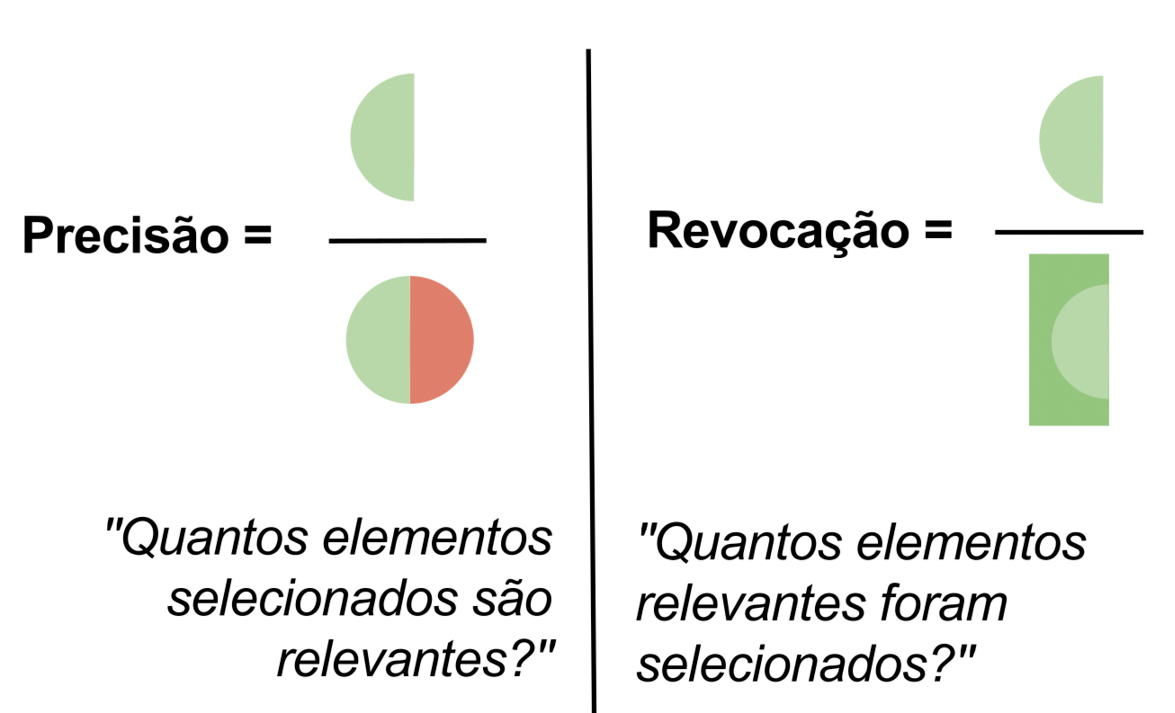

In [83]:
# Report de classificação e Matriz de confusão

# Trás métricas:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.59      0.65      0.62       136

    accuracy                           1.00     85443
   macro avg       0.80      0.83      0.81     85443
weighted avg       1.00      1.00      1.00     85443



### Matriz de Confusão
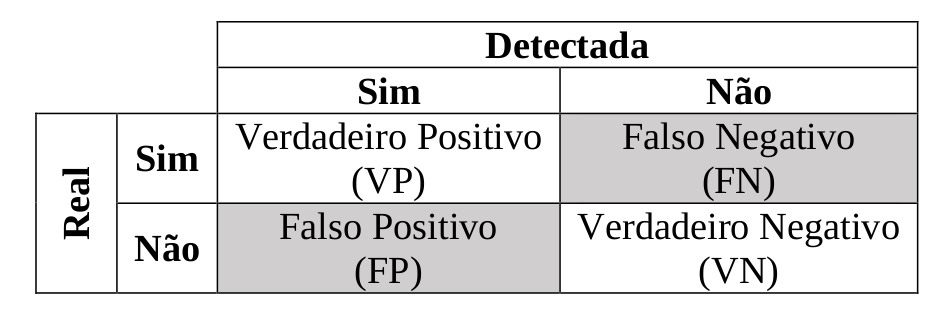

Primeira coluna é o que é predito como não fraude
Segunda coluna é o que foi predito como fraude

Primeira linha o que realmnete não era fraude
Segunda linha o que realmnete era fraude

O falso positivo é o erro que não se deseja, porque é algo que está errado mas sendo apontado como verdadeiro. Esse valor é o menos desejado e o que mais deve ser trabalhado para reduzir isso.

***Em resumo: Quanto menor for o FN e o FP melhor, consequentemente com sua redução o VP e o VN melhoram***

<Axes: >

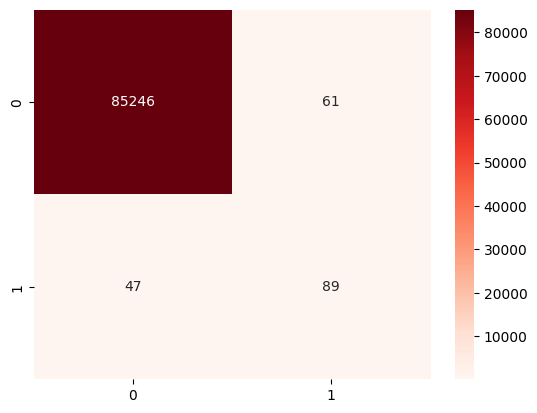

In [84]:
# Forma de visualizar o desempenho do modelo, mostrando a quantidade de verdadeiros positivos, falsos positivos, verdadeiros negativos e falsos negativos.

# Matrix de Confusão, que recebe as mesmas coisas que o classification_report, ou seja, os dados de teste e as predições do modelo.
conf_matrix = confusion_matrix(y_test, y_pred_baseline)

# Visualização da matriz de confusão usando seaborn
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds")

### Melhorar precisão (Precision) do modelo de classificação

In [85]:
# Pegar 5 exemplos de fraude do dataset para mostrar ao LLM
df_fraudes_reais = X_train[y_train == 1].sample(5)

# Formatando os exemplos para o promot (Few-Shot Prompting)
exemplos_texto = ""

# Interações a cada linha dos dados reais pegando classe == 1
for i, row in df_fraudes_reais.iterrows():
  exemplos_texto += f"Exemplo de transação fraudulenta {i+1}:\n"
  # concatena qual a linha e registro
  exemplos_texto += str(row.to_dict()) + "\n\n"

print(exemplos_texto)

prompt_geracao = f"""
Você é um especialista em ciência de dados simulando dados para um modelo de detecção de fraude.
Com base nos exemplos de transações fraudulentas abaixo, gere 10 novos exemplos de transações fictícias, mas realistas, que sigam um padrão similar.
Retorne apenas os dicionários de dados, um por linha, sem texto adicional.

{exemplos_texto}

Gere 10 novos exemplos aqui:
"""

Exemplo de transação fraudulenta 261057:
{'Time': 159844.0, 'V1': -0.408110816961726, 'V2': 3.13294449795257, 'V3': -3.09802976350239, 'V4': 5.80389261500645, 'V5': 0.890608919007457, 'V6': -0.501474323471098, 'V7': -0.440054283341639, 'V8': 0.591828268527081, 'V9': -3.26769325879204, 'V10': -2.22307032799021, 'V11': 0.757063214391669, 'V12': -3.5018037792943, 'V13': 0.246742224128631, 'V14': -6.0656218797665, 'V15': 0.339583134189158, 'V16': -1.00572315400358, 'V17': 0.334315623693923, 'V18': 0.421261362446254, 'V19': 1.24714263088632, 'V20': 0.499567913131525, 'V21': 0.0984823222449585, 'V22': -0.538374705312947, 'V23': -0.217988987498016, 'V24': -1.04265661749863, 'V25': 0.314388820647828, 'V26': 0.54324357594221, 'V27': 0.233851015408581, 'V28': 0.119603460907874, 'Amount': 45.51}

Exemplo de transação fraudulenta 57471:
{'Time': 47923.0, 'V1': 0.364376991240021, 'V2': 1.44352346510311, 'V3': -2.2209073739296, 'V4': 2.03698508634993, 'V5': -1.23705503097364, 'V6': -1.72816100636381

In [86]:
print(prompt_geracao)


Você é um especialista em ciência de dados simulando dados para um modelo de detecção de fraude.
Com base nos exemplos de transações fraudulentas abaixo, gere 10 novos exemplos de transações fictícias, mas realistas, que sigam um padrão similar.
Retorne apenas os dicionários de dados, um por linha, sem texto adicional.

Exemplo de transação fraudulenta 261057:
{'Time': 159844.0, 'V1': -0.408110816961726, 'V2': 3.13294449795257, 'V3': -3.09802976350239, 'V4': 5.80389261500645, 'V5': 0.890608919007457, 'V6': -0.501474323471098, 'V7': -0.440054283341639, 'V8': 0.591828268527081, 'V9': -3.26769325879204, 'V10': -2.22307032799021, 'V11': 0.757063214391669, 'V12': -3.5018037792943, 'V13': 0.246742224128631, 'V14': -6.0656218797665, 'V15': 0.339583134189158, 'V16': -1.00572315400358, 'V17': 0.334315623693923, 'V18': 0.421261362446254, 'V19': 1.24714263088632, 'V20': 0.499567913131525, 'V21': 0.0984823222449585, 'V22': -0.538374705312947, 'V23': -0.217988987498016, 'V24': -1.04265661749863, '

In [87]:
# Modelo de IA Generativa (utilizar)
model_gen = genai.GenerativeModel('gemini-2.5-flash')
response = model_gen.generate_content(prompt_geracao)

In [88]:
print(response.text)

{'Time': 97845.1, 'V1': -1.979020165983768, 'V2': 3.840134047649233, 'V3': -6.829377402095945, 'V4': 4.192385966453724, 'V5': -0.923458476839078, 'V6': -1.638210086872589, 'V7': -4.590234791535977, 'V8': 1.127891899120658, 'V9': -2.10091216550298, 'V10': -6.219503378521768, 'V11': 6.039478143003028, 'V12': -9.00839843343048, 'V13': 1.583092671500351, 'V14': -8.140237748883654, 'V15': -0.098492067825227, 'V16': -7.027581372722238, 'V17': -8.54920150974864, 'V18': -2.802345689123659, 'V19': 2.894378129524036, 'V20': 0.612013894572236, 'V21': 1.570238122390884, 'V22': 0.748378943360216, 'V23': -0.158378401833075, 'V24': -0.785234591230121, 'V25': 0.283945903472096, 'V26': 0.380123547892012, 'V27': 0.398345712390123, 'V28': -0.089234587391231, 'Amount': 2.37}
{'Time': 56789.0, 'V1': -2.89736891273468, 'V2': 2.508934578123098, 'V3': -4.567891234567891, 'V4': 3.109876543210987, 'V5': -0.801234567890123, 'V6': -1.987654321098765, 'V7': -3.890123456789012, 'V8': -0.567890123456789, 'V9': -1.90

In [89]:
# Processando a resposta do LLM para transforma-la em um DataFrame
novas_fraudes = []

# A resposta do LLM é uma string, onde cada linha é um dicionário de dados. O código abaixo percorre cada linha da resposta, tenta avaliar a string como um dicionário Python usando ast.literal_eval, e se for bem-sucedido, adiciona o dicionário à lista de novas fraudes. Se a linha não for um dicionário válido, ela é ignorada.
for line in response.text.strip().split("\n"):
  try: 
    # ast.literal_eval é uma função que avalia uma string contendo uma expressão Python e retorna o resultado da avaliação. Ele é usado para converter a string de volta para um dicionário Python.
    novas_fraudes.append(ast.literal_eval(line))
  except:
    continue # Ignora linhas mal formatadas


In [90]:
# Criando novo DataFrame
df_novas_fraudes = pd.DataFrame(novas_fraudes)

df_novas_fraudes['Class'] = 1

df_novas_fraudes

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,97845.1,-1.979020,3.840134,-6.829377,4.192386,-0.923458,-1.638210,-4.590235,1.127892,-2.100912,...,1.570238,0.748379,-0.158378,-0.785235,0.283946,0.380124,0.398346,-0.089235,2.37,1
1,56789.0,-2.897369,2.508935,-4.567891,3.109877,-0.801235,-1.987654,-3.890123,-0.567890,-1.901235,...,0.901235,-0.345679,-0.190123,-0.234568,0.123457,0.310988,0.190123,0.056789,15.89,1
2,123456.7,-0.890123,4.123457,-3.901235,5.109877,0.123457,-0.987654,-2.901235,0.890123,-2.890123,...,0.189012,-0.789012,-0.123457,-0.567890,0.390123,0.456789,0.290123,0.089012,34.50,1
3,78901.2,-3.567890,1.890123,-7.109877,4.890123,-1.567890,-2.109877,-4.109877,-1.567890,-3.109877,...,1.789012,0.901235,-0.356789,-0.901235,0.489012,0.190123,-0.109877,-0.567890,5.00,1
4,45678.9,-1.234568,3.109877,-2.890123,2.890123,-0.567890,-1.234568,-2.567890,0.123457,-1.567890,...,0.390123,-0.234568,-0.056789,0.123457,0.456789,0.356789,0.490123,0.190123,0.99,1
5,101101.1,-0.123457,4.567890,-5.109877,5.890123,0.567890,-0.678901,-1.901235,0.789012,-3.109877,...,0.109877,-0.678901,-0.290123,-0.890123,0.190123,0.490123,0.189012,0.090123,55.20,1
6,150000.0,0.890123,2.109877,-3.109877,4.109877,-0.123457,-1.123457,-1.901235,0.390123,-2.109877,...,0.256789,-0.190123,-0.034568,-0.390123,0.156789,0.109877,0.456789,0.201235,1.00,1
7,80000.0,-2.109877,3.567890,-6.109877,4.567890,-1.109877,-1.890123,-3.109877,0.901235,-2.567890,...,1.109877,0.567890,-0.289012,-0.567890,0.256789,0.156789,0.109877,-0.123457,12.50,1
8,65432.1,-3.109877,2.890123,-3.567890,1.890123,-1.890123,-1.901235,-3.109877,-1.109877,-0.567890,...,1.567890,-0.890123,-0.310988,0.109877,-0.056789,0.256789,-0.290123,-0.678901,42.00,1
9,110000.0,-2.567890,4.109877,-7.109877,5.109877,-1.567890,-2.109877,-4.567890,1.109877,-2.890123,...,1.109877,0.890123,-0.256789,-0.390123,0.310988,0.109877,0.156789,-0.190123,2.00,1


In [91]:
#  Criação de um novo modelo passando uma regressão logistica, passando x e y com eles aumentados.
# Onde X_augmented é a combinação dos dados originais de treino (X_train) com as novas fraudes geradas pelo LLM (df_novas_fraudes.drop("Class", axis=1)), e y_augmented é a combinação dos rótulos originais de treino (y_train) com os rótulos das novas fraudes (df_novas_fraudes["Class"]).


print("\n--- 🚀 Treinando nosso Modelo Aprimorado com Dados Sintéticos ---")
X_train_aumentado = pd.concat([X_train, df_novas_fraudes.drop('Class', axis=1)], ignore_index=True)
y_train_aumentado = pd.concat([y_train, df_novas_fraudes['Class']], ignore_index=True)

model_melhorado = LogisticRegression()
# Treina o modelo de regressão logística usando os dados de treino aumentados, que incluem tanto os dados originais quanto as novas fraudes geradas pelo LLM.
model_melhorado.fit(X_train_aumentado, y_train_aumentado)
y_pred_melhorado = model_melhorado.predict(X_test)


--- 🚀 Treinando nosso Modelo Aprimorado com Dados Sintéticos ---


C:\Users\gusta\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [92]:
# Comparando os resultados

print("\n--- Resultado do Modelo Baseline ---")
print(classification_report(y_test, y_pred_baseline))


print("\n--- Resultado do Modelo Aprimorado ---")
print(classification_report(y_test, y_pred_melhorado))


--- Resultado do Modelo Baseline ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.59      0.65      0.62       136

    accuracy                           1.00     85443
   macro avg       0.80      0.83      0.81     85443
weighted avg       1.00      1.00      1.00     85443


--- Resultado do Modelo Aprimorado ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.68      0.72      0.70       136

    accuracy                           1.00     85443
   macro avg       0.84      0.86      0.85     85443
weighted avg       1.00      1.00      1.00     85443



Text(0.5, 1.0, 'Matriz de Confusão - Modelo Baseline')

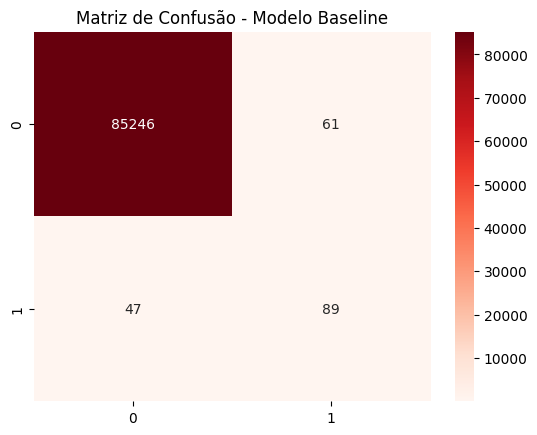

In [93]:
sns.heatmap(confusion_matrix(y_test, y_pred_baseline), annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusão - Modelo Baseline')

Text(0.5, 1.0, 'Matriz de Confusão - Modelo Aprimorado com GenAI')

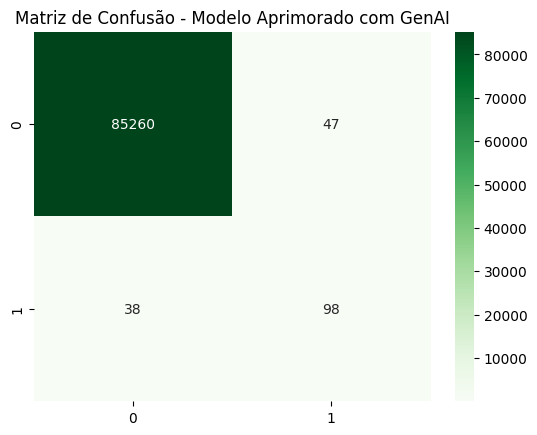

In [94]:
sns.heatmap(confusion_matrix(y_test, y_pred_melhorado), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Modelo Aprimorado com GenAI')

## Melhorias propostas

- Utiliar **SMOTE (Synthetic Minority Over-sampling Technique)** ao invés de uma LLM. O SMOTE é uma técnica que usa algotimos geométricos apra criar milhares de exmeplos sintéticos que respeitam a matemática do dataset
- Ajustes de Pesos (Class Weight): model = LogisticRegression(class_weight='balanced')
